# Notebook 03 : Keras Training: RNN & LSTM Image Captioning Decoder

Variasi:
- recurrent layers: 1, 2, 3
- Hidden state size: 128, 256


| Variant | Layers | Hidden |
|---------|--------|--------|
| V1 | 1 | 128 |
| V2 | 1 | 256 |
| V3 | 2 | 128 |
| V4 | 2 | 256 |
| V5 | 3 | 128 |
| V6 | 3 | 256 |

## Imports & Config

In [7]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/usr/lib/cuda --xla_gpu_enable_triton_gemm=false"
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

PROJECT_ROOT = Path().resolve().parent.parent
DATA_DIR     = PROJECT_ROOT / 'data' / '2_rnn_image_captioning'
FEATURE_DIR  = DATA_DIR / 'features'
WEIGHTS_DIR  = PROJECT_ROOT / 'models' / 'rnn_lstm'
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

EMBED_DIM   = 128
EPOCHS      = 20
BATCH_SIZE  = 32
CNN_FEATURE_DIM = 2048  # InceptionV3 avg pool output

TRAIN_SPLIT = 6000
VAL_SPLIT   = 1000
TEST_SPLIT  = 1000 

VARIATIONS = [
    {'layers': 1, 'hidden': 128},
    {'layers': 1, 'hidden': 256},
    {'layers': 2, 'hidden': 128},
    {'layers': 2, 'hidden': 256},
    {'layers': 3, 'hidden': 128},
    {'layers': 3, 'hidden': 256},
]

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)  
    print(f'GPU ready: {[g.name for g in gpus]}')
else:
    print('No GPU found — running on CPU.')

GPU ready: ['/physical_device:GPU:0']


## Load Data

In [8]:
padded_sequences = np.load(DATA_DIR / 'processed_captions.npy')
image_ids        = np.load(DATA_DIR / 'image_ids.npy', allow_pickle=True)

with open(DATA_DIR / 'config.json') as f:
    config = json.load(f)
MAX_LEN   = config['max_length']
VOCAB_SIZE = config['vocab_size']

print(f'Sequences shape : {padded_sequences.shape}')
print(f'Image IDs shape : {image_ids.shape}')
print(f'Max length      : {MAX_LEN}')
print(f'Vocab size      : {VOCAB_SIZE}')

Sequences shape : (40455, 38)
Image IDs shape : (40455,)
Max length      : 38
Vocab size      : 8832


## Load CNN Features & Build Lookup

In [9]:
feature_cache = {}
for npy_file in FEATURE_DIR.glob('*.npy'):
    img_id = npy_file.stem
    feature_cache[img_id] = np.load(npy_file)

print(f'Loaded {len(feature_cache)} image features.')

sample_key = next(iter(feature_cache))
print(f'Feature vector shape: {feature_cache[sample_key].shape}')

Loaded 8091 image features.
Feature vector shape: (2048,)


## Build Training Pairs (Pre-inject)

In [10]:
def build_dataset(sequences, img_ids, feature_cache, max_len):
    img_features = []
    caption_inputs = []
    caption_targets = []

    skipped = 0
    for seq, img_id in zip(sequences, img_ids):
        if img_id not in feature_cache:
            skipped += 1
            continue
        feat = feature_cache[img_id]  
        cap_in  = seq[:-1]  
        cap_out = seq[1:] 

        img_features.append(feat)
        caption_inputs.append(cap_in)
        caption_targets.append(cap_out)

    if skipped > 0:
        print(f'Warning: skipped {skipped} captions (missing features).')

    return (
        np.array(img_features, dtype=np.float32),
        np.array(caption_inputs, dtype=np.int32),
        np.array(caption_targets, dtype=np.int32)
    )


unique_ids = list(dict.fromkeys(image_ids))
train_ids  = set(unique_ids[:TRAIN_SPLIT])
val_ids    = set(unique_ids[TRAIN_SPLIT:TRAIN_SPLIT + VAL_SPLIT])
test_ids  = set(unique_ids[TRAIN_SPLIT + VAL_SPLIT : TRAIN_SPLIT + VAL_SPLIT + TEST_SPLIT])

train_mask = np.array([img_id in train_ids for img_id in image_ids])
val_mask   = np.array([img_id in val_ids   for img_id in image_ids])
test_mask = np.array([img_id in test_ids for img_id in image_ids])

train_feats, train_cap_in, train_cap_out = build_dataset(
    padded_sequences[train_mask], image_ids[train_mask], feature_cache, MAX_LEN)
val_feats,   val_cap_in,   val_cap_out   = build_dataset(
    padded_sequences[val_mask],   image_ids[val_mask],   feature_cache, MAX_LEN)
test_feats, test_cap_in, test_cap_out = build_dataset(
    padded_sequences[test_mask], image_ids[test_mask], feature_cache, MAX_LEN)

print(f'Train samples : {len(train_feats)}')
print(f'Val   samples : {len(val_feats)}')
print(f'Test samples: {len(test_feats)}')
print(f'Caption input shape  : {train_cap_in.shape}')
print(f'Caption target shape : {train_cap_out.shape}')

Train samples : 30000
Val   samples : 5000
Test samples: 5000
Caption input shape  : (30000, 37)
Caption target shape : (30000, 37)


## Model Builder

In [11]:
def build_decoder(cell_type, num_layers, hidden_size, vocab_size, embed_dim, max_len, cnn_dim):

    assert cell_type in ('rnn', 'lstm')

    img_input = keras.Input(shape=(cnn_dim,), name='image_feature')
    cap_input = keras.Input(shape=(max_len - 1,), dtype='int32', name='caption_input')

    img_proj = layers.Dense(embed_dim, name='image_projection')(img_input)   
    img_proj = layers.Reshape((1, embed_dim), name='image_expand')(img_proj) 

    cap_emb = layers.Embedding(vocab_size, embed_dim, name='embedding')(cap_input)  

    x = layers.Concatenate(axis=1, name='sequence_input')([img_proj, cap_emb])

    for i in range(num_layers):
        return_sequences = True 
        name = f'{cell_type}_{i+1}'
        if cell_type == 'rnn':
            x = layers.SimpleRNN(hidden_size, return_sequences=return_sequences, name=name)(x)
        else:
            x = layers.LSTM(hidden_size, return_sequences=return_sequences, name=name)(x)

    x = layers.Lambda(lambda t: t[:, 1:, :], name='slice_output')(x)

    output = layers.Dense(vocab_size, activation='softmax', name='output')(x)

    model = keras.Model(inputs=[img_input, cap_input], outputs=output)
    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Training Loop

In [12]:
histories = {'rnn': {}, 'lstm': {}}

for cell_type in ['rnn', 'lstm']:
    for i, var in enumerate(VARIATIONS, start=1):
        n_layers = var['layers']
        hidden   = var['hidden']
        tag      = f'{cell_type}_v{i}_L{n_layers}_H{hidden}'
        weights_path = WEIGHTS_DIR / f'{tag}.keras'

        print(f'\n{"-"*60}')
        print(f'Training {tag}')
        print(f'{"-"*60}')

        model = build_decoder(cell_type, n_layers, hidden, VOCAB_SIZE, EMBED_DIM, MAX_LEN, CNN_FEATURE_DIM)

        callbacks = [
            ModelCheckpoint(
                filepath=str(weights_path),
                monitor='val_loss',
                save_best_only=True,
                verbose=0
            ),
            EarlyStopping(
                monitor='val_loss',
                patience=5,
                restore_best_weights=True,
                verbose=1
            )
        ]

        history = model.fit(
            x=[train_feats, train_cap_in],
            y=train_cap_out,
            validation_data=([val_feats, val_cap_in], val_cap_out),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=callbacks,
            verbose=1
        )

        histories[cell_type][tag] = history.history
        print(f'Saved best weights : {weights_path}')


------------------------------------------------------------
Training rnn_v1_L1_H128
------------------------------------------------------------
Epoch 1/20


W0000 00:00:1778751822.752576    1648 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1778751822.868694    1648 dot_merger.cc:481] Merging Dots in computation: functional_2_1_rnn_1_1_while_body_25607_grad_25819_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778751822.868916    1648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26387__.28


937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7211 - loss: 2.4091

W0000 00:00:1778751845.247438    1646 assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1778751845.341784    1646 dot_merger.cc:481] Merging Dots in computation: functional_2_1_rnn_1_1_while_body_25607_grad_25819_const_0__.24.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778751845.341966    1646 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_26387__.28


938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7212 - loss: 2.4083

...

938/938 ━━━━━━━━━━━━━━━━━━━━ 46s 45ms/step - accuracy: 0.7477 - loss: 1.6938 - val_accuracy: 0.7750 - val_loss: 1.2861
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.7853 - loss: 1.1787 - val_accuracy: 0.7839 - val_loss: 1.1886
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.7929 - loss: 1.0867 - val_accuracy: 0.7888 - val_loss: 1.1445
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.7977 - loss: 1.0311 - val_accuracy: 0.7917 - val_loss: 1.1197
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8009 - loss: 0.9915 - val_accuracy: 0.7935 - val_loss: 1.1021
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 45ms/step - accuracy: 0.8036 - loss: 0.9604 - val_accuracy: 0.7948 - val_loss: 1.0957
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step - accuracy: 0.8062 - loss: 0.9344 - val_accuracy: 0.7950 - val_loss: 1.0921
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 41s 44ms/step - accuracy: 0.8082 - loss: 0.9121 - val_accurac

I0000 00:00:1778753959.946955    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_3_1_while_body_332310_grad_332522_const_0__.34.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778753959.947100    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_2_1_while_body_332199_grad_332742_const_0__.40.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778753959.947143    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_1_1_while_body_332088_grad_332962_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778753959.947180    1649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_333740__.50


937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7256 - loss: 2.0654

I0000 00:00:1778754010.026243    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_3_1_while_body_332310_grad_332522_const_0__.34.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778754010.026435    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_2_1_while_body_332199_grad_332742_const_0__.40.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778754010.026498    1649 dot_merger.cc:481] Merging Dots in computation: functional_7_1_rnn_1_1_while_body_332088_grad_332962_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1778754010.026550    1649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_333740__.50


938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.7570 - loss: 1.5306 - val_accuracy: 0.7739 - val_loss: 1.2841
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 51s 54ms/step - accuracy: 0.7833 - loss: 1.1827 - val_accuracy: 0.7833 - val_loss: 1.1933
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.7908 - loss: 1.0926 - val_accuracy: 0.7860 - val_loss: 1.1566
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - accuracy: 0.7946 - loss: 1.0391 - val_accuracy: 0.7898 - val_loss: 1.1378
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.7974 - loss: 0.9978 - val_accuracy: 0.7900 - val_loss: 1.1294
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 53ms/step - accuracy: 0.7998 - loss: 0.9648 - val_accuracy: 0.7932 - val_loss: 1.1097
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.8017 - loss: 0.9381 - val_accuracy: 0.7934 - val_loss: 1.1082
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.8037 - loss: 0.9157 - val_accurac

## Save Training Histories

In [13]:
import json

histories_serializable = {}
for cell_type, variants in histories.items():
    histories_serializable[cell_type] = {}
    for tag, hist in variants.items():
        histories_serializable[cell_type][tag] = {
            k: [float(v) for v in vals] for k, vals in hist.items()
        }

history_path = WEIGHTS_DIR / 'training_histories.json'
with open(history_path, 'w') as f:
    json.dump(histories_serializable, f, indent=2)

print(f'Histories saved to {history_path}')

Histories saved to /home/benth/Tugas/Tubes2_AnakRudyKusdiantara/models/rnn_lstm/training_histories.json


## Training Loss / Validation Loss Plots

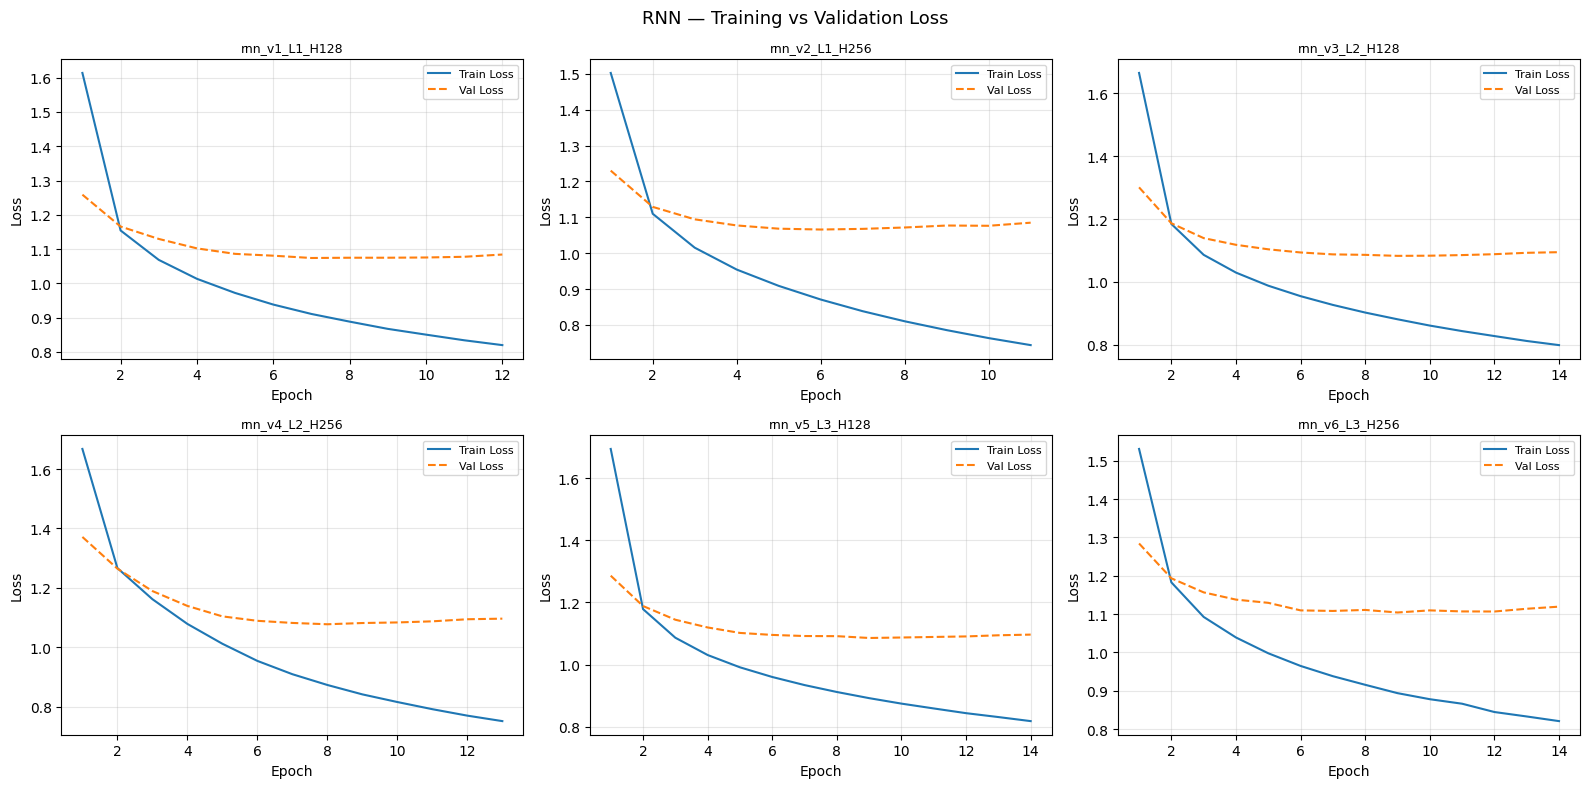

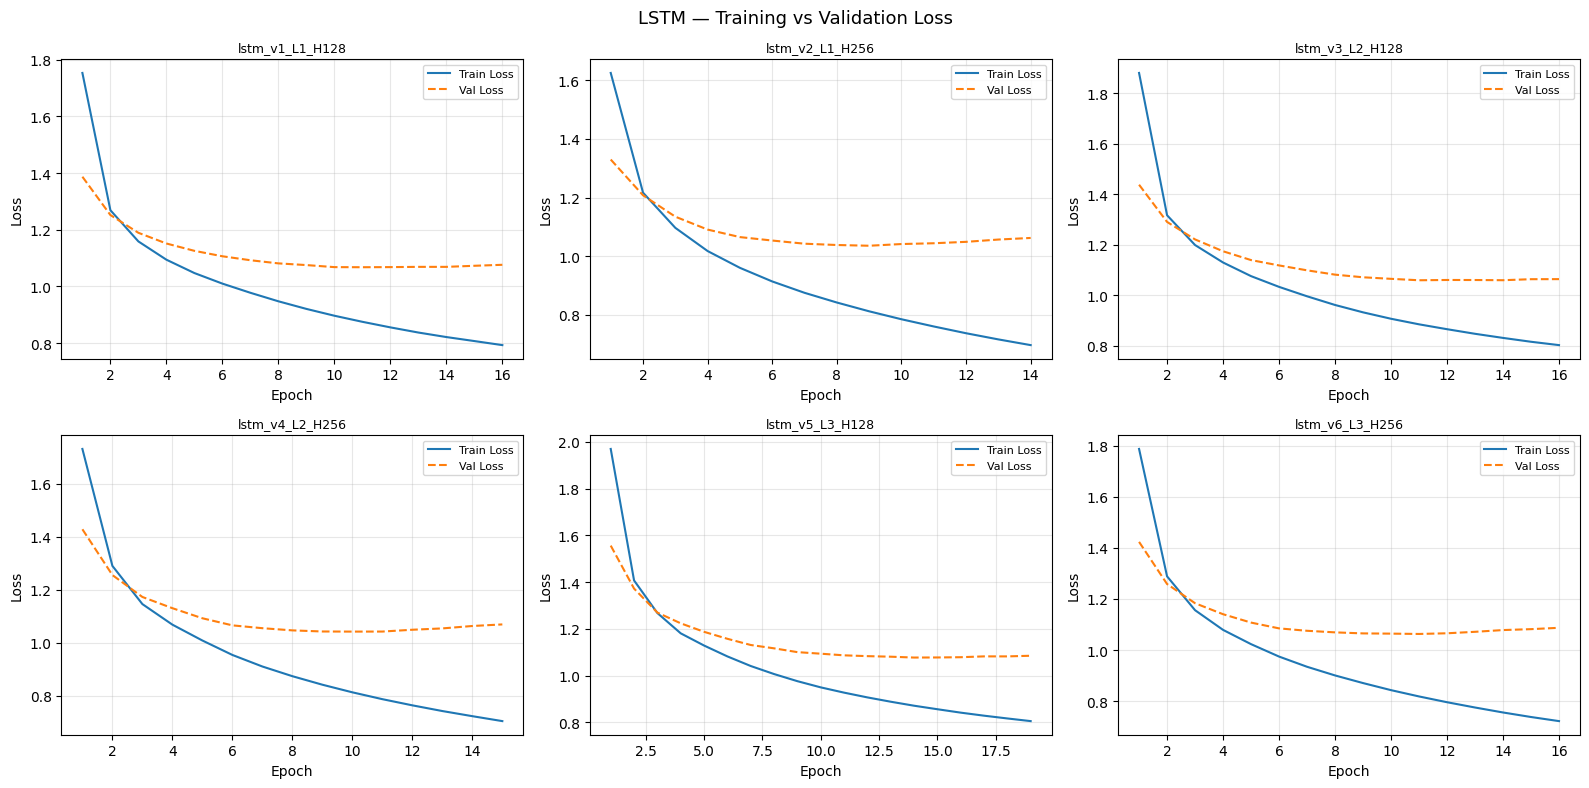

In [14]:
def plot_histories(histories_dict, cell_type):
    variants = histories_dict[cell_type]
    n = len(variants)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()

    for ax, (tag, hist) in zip(axes, variants.items()):
        epochs = range(1, len(hist['loss']) + 1)
        ax.plot(epochs, hist['loss'],     label='Train Loss')
        ax.plot(epochs, hist['val_loss'], label='Val Loss', linestyle='--')
        ax.set_title(tag, fontsize=9)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    fig.suptitle(f'{cell_type.upper()} — Training vs Validation Loss', fontsize=13)
    plt.tight_layout()
    plt.savefig(WEIGHTS_DIR / f'{cell_type}_loss_curves.png', dpi=150)
    plt.show()

plot_histories(histories, 'rnn')
plot_histories(histories, 'lstm')

In [15]:
rows = []
for cell_type in ['rnn', 'lstm']:
    for tag, hist in histories[cell_type].items():
        best_val_loss   = min(hist['val_loss'])
        best_epoch      = hist['val_loss'].index(best_val_loss) + 1
        final_train_loss = hist['loss'][-1]
        _, var_info     = tag.split('_v')
        parts           = var_info.split('_')
        n_layers        = int(parts[1][1:])
        hidden          = int(parts[2][1:])
        rows.append({
            'tag': tag,
            'cell': cell_type.upper(),
            'layers': n_layers,
            'hidden': hidden,
            'best_val_loss': round(best_val_loss, 4),
            'best_epoch': best_epoch,
            'final_train_loss': round(final_train_loss, 4)
        })

df_summary = pd.DataFrame(rows).sort_values('best_val_loss')
print(df_summary.to_string(index=False))

best_rnn  = df_summary[df_summary['cell'] == 'RNN'].iloc[0]
best_lstm = df_summary[df_summary['cell'] == 'LSTM'].iloc[0]
print(f'\nBest RNN  variant: {best_rnn["tag"]} (val_loss={best_rnn["best_val_loss"]})')
print(f'Best LSTM variant: {best_lstm["tag"]} (val_loss={best_lstm["best_val_loss"]})')

            tag cell  layers  hidden  best_val_loss  best_epoch  final_train_loss
lstm_v2_L1_H256 LSTM       1     256         1.0358           9            0.6972
lstm_v4_L2_H256 LSTM       2     256         1.0425          10            0.7053
lstm_v3_L2_H128 LSTM       2     128         1.0598          11            0.8032
lstm_v6_L3_H256 LSTM       3     256         1.0629          11            0.7219
 rnn_v2_L1_H256  RNN       1     256         1.0659           6            0.7437
lstm_v1_L1_H128 LSTM       1     128         1.0676          11            0.7927
 rnn_v1_L1_H128  RNN       1     128         1.0740           7            0.8199
 rnn_v4_L2_H256  RNN       2     256         1.0775           8            0.7514
lstm_v5_L3_H128 LSTM       3     128         1.0775          14            0.8058
 rnn_v3_L2_H128  RNN       2     128         1.0829           9            0.7990
 rnn_v5_L3_H128  RNN       3     128         1.0859           9            0.8185
 rnn_v6_L3_H256 